# Lecture: Convolutional Neural Networks (CNN)

MTU Spring 2025

Instructor: Amna Mazen

## Learning outcomes
- Your first CV model (Yay!)
- Understanding CNN
- What Conv nets learn

## MNIST dataset

### Step 1: Get Kaggle API Token
- Go to https://www.kaggle.com
- Click on your profile icon in the top-right corner and select **settings**
- Scroll down to the **API** section and click "**Create New API Token**"
- A file named **kaggle.json** will be downloaded — do not open it, just upload it in the next step

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"amnamazenali","key":"fab34df9dd5026805338be32cf4f91af"}'}

### Step 3: Set Up Kaggle API Access

In [ ]:
import os
import zipfile

# Create Kaggle directory
os.makedirs("/root/.kaggle", exist_ok=True)

# Move kaggle.json to the right location
!mv kaggle.json /root/.kaggle/

# Set proper permissions
!chmod 600 /root/.kaggle/kaggle.json

### Step 4: Download the Dataset from Kaggle

In [ ]:
!kaggle competitions download -c digit-recognizer
!unzip digit-recognizer.zip

Archive:  digit-recognizer.zip
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               


**Explanation:**

! → The exclamation mark is used in Colab to run shell commands (Linux commands) directly in the notebook.

kaggle → Refers to the Kaggle command-line tool, which interacts with Kaggle's API.

competitions → Specifies that the dataset is part of a Kaggle competition (instead of a standalone dataset).

download → Instructs Kaggle to download the dataset.

-c digit-recognizer → The -c flag is used to specify the competition name, which in this case is "digit-recognizer".

### Task: Load a Kaggle Dataset in Google Colab


Learn how to download and load a dataset from Kaggle into Google Colab for further analysis.

**Dataset:**

We will use the **"Titanic - Machine Learning from Disaster"** dataset, which is small and easy to work with.

**Steps:**


1.   Get Kaggle API Token
2.   Upload kaggle.json to Google Colab
3. Install Kaggle and Configure API
4. Download the Titanic Dataset:

```!kaggle competitions download -c titanic```
5. Unzip the downloaded file:

```python
import zipfile
with zipfile.ZipFile("titanic.zip", "r") as zip_ref:
    zip_ref.extractall("titanic_data")


6.  Load the Dataset into Pandas and display the first 5 rows

### Load the Data
The dataset consists of:

train.csv (Training set: images + labels)

test.csv (Test set: images without labels)

In [ ]:
import pandas as pd
import numpy as np
import keras
from keras import layers
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical

# Load train.csv
train = pd.read_csv("train.csv")

print(train.shape)
train.head()




(42000, 785)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# read test
test= pd.read_csv("test.csv")
print(test.shape)
test.head()

(28000, 784)


,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# put labels into y_train variable
Y_train = train["label"]
# Drop 'label' column
X_train = train.drop(labels = ["label"],axis = 1)

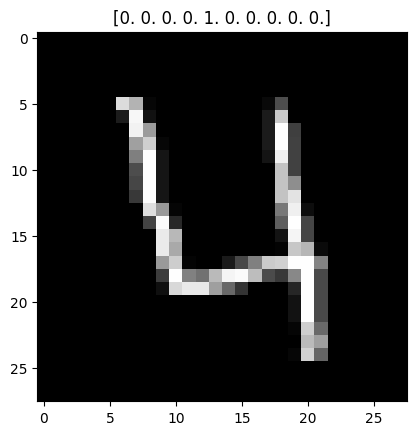

In [ ]:
# plot some samples
import matplotlib.pyplot as plt

# Extract first image
img = X_train.iloc[3].values
img = img.reshape((28, 28))  # Reshape to 28x28

# Plot the image
plt.imshow(img, cmap='gray')
plt.title(y_train[3])  # Display label
plt.show()

### Normalization, Reshape and Label Encoding¶
- Normalization

We perform a grayscale normalization to reduce the effect of illumination's differences.

If we perform normalization, CNN works faster.

- Reshape

Train and test images (28 x 28)

We reshape all data to 28x28x1 3D matrices.

Keras needs an extra dimension in the end which correspond to channels. Our images are gray scaled so it use only one channel.

- Label Encoding

Encode labels to one hot vectors

2 => [0,0,1,0,0,0,0,0,0,0]

4 => [0,0,0,0,1,0,0,0,0,0]

In [ ]:
# Normalize the data
X_train = X_train / 255.0
test = test / 255.0
print("x_train shape: ",X_train.shape)
print("test shape: ",test.shape)

x_train shape:  (42000, 784)
test shape:  (28000, 784)


In [ ]:
# Reshape
X_train = X_train.values.reshape(-1,28,28,1)
test = test.values.reshape(-1,28,28,1)
print("x_train shape: ",X_train.shape)
print("test shape: ",test.shape)

x_train shape:  (42000, 28, 28, 1)
test shape:  (28000, 28, 28, 1)


In [ ]:
# Label Encoding
Y_train = to_categorical(Y_train, num_classes = 10)

### Train Test Split
We split the data into train and test sets.
- test size is 10%.
- train size is 90%.

In [ ]:
# Split the train and the validation set for the fitting
from sklearn.model_selection import train_test_split
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size = 0.1, random_state=2)
print("x_train shape",X_train.shape)
print("x_test shape",X_val.shape)
print("y_train shape",Y_train.shape)
print("y_test shape",Y_val.shape)

x_train shape (37800, 28, 28, 1)
x_test shape (4200, 28, 28, 1)
y_train shape (37800, 10)
y_test shape (4200, 10)


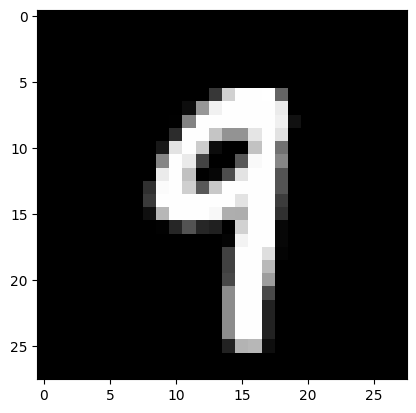

In [ ]:
# Some examples
plt.imshow(X_train[2][:,:,0],cmap='gray')
plt.show()

### Create a model

In [ ]:
from sklearn.metrics import confusion_matrix
import itertools


from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
from keras.optimizers import RMSprop,Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ReduceLROnPlateau

model = Sequential()
#
model.add(Conv2D(filters = 8, kernel_size = (5,5),padding = 'Same',
                 activation ='relu', input_shape = (28,28,1)))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.25))
#
model.add(Conv2D(filters = 16, kernel_size = (3,3),padding = 'Same',
                 activation ='relu'))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))
model.add(Dropout(0.25))
# fully connected
model.add(Flatten())
model.add(Dense(256, activation = "relu"))
model.add(Dropout(0.5))
model.add(Dense(10, activation = "softmax"))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### Define Optimizer

Adam optimizer: Change the learning rate

In [ ]:
# Define the optimizer
optimizer = Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)

# Compile the model
model.compile(optimizer = optimizer , loss = "categorical_crossentropy", metrics=["accuracy"])

**What Is the Difference Between Batch and Epoch?**

- The batch size is a number of samples processed before the model is updated.

- The number of epochs is the number of complete passes through the training dataset.

The size of a batch must be more than or equal to one and less than or equal to the number of samples in the training dataset.

In [ ]:
epochs = 20  # for better result increase the epochs
batch_size = 250

### Data Augmentation
- To avoid overfitting problem, we need to expand artificially our handwritten digit dataset

- Alter the training data with small transformations to reproduce the variations of digit.
- For example, the number is not centered The scale is not the same (some who write with big/small numbers) The image is rotated.


In [ ]:
# data augmentation
datagen = ImageDataGenerator(
        featurewise_center=False,  # set input mean to 0 over the dataset
        samplewise_center=False,  # set each sample mean to 0
        featurewise_std_normalization=False,  # divide inputs by std of the dataset
        samplewise_std_normalization=False,  # divide each input by its std
        zca_whitening=False,  # dimesion reduction
        rotation_range=5,  # randomly rotate images in the range 5 degrees
        zoom_range = 0.1, # Randomly zoom image 10%
        width_shift_range=0.1,  # randomly shift images horizontally 10%
        height_shift_range=0.1,  # randomly shift images vertically 10%
        horizontal_flip=False,  # randomly flip images
        vertical_flip=False)  # randomly flip images

datagen.fit(X_train)

In [ ]:
# Fit the model
history = model.fit(datagen.flow(X_train, Y_train, batch_size=batch_size),
                    epochs=epochs, validation_data=(X_val, Y_val),
                    steps_per_epoch=X_train.shape[0] // batch_size)

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


151/151 ━━━━━━━━━━━━━━━━━━━━ 32s 213ms/step - accuracy: 0.9335 - loss: 0.2169 - val_accuracy: 0.9771 - val_loss: 0.0780
Epoch 2/20
  1/151 ━━━━━━━━━━━━━━━━━━━━ 17s 119ms/step - accuracy: 0.9400 - loss: 0.1655

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9400 - loss: 0.1655 - val_accuracy: 0.9786 - val_loss: 0.0767
Epoch 3/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 31s 204ms/step - accuracy: 0.9371 - loss: 0.2044 - val_accuracy: 0.9786 - val_loss: 0.0714
Epoch 4/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9400 - loss: 0.1829 - val_accuracy: 0.9793 - val_loss: 0.0710
Epoch 5/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 31s 208ms/step - accuracy: 0.9416 - loss: 0.1864 - val_accuracy: 0.9802 - val_loss: 0.0672
Epoch 6/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9520 - loss: 0.1224 - val_accuracy: 0.9807 - val_loss: 0.0671
Epoch 7/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 31s 203ms/step - accuracy: 0.9412 - loss: 0.1894 - val_accuracy: 0.9833 - val_loss: 0.0610
Epoch 8/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9320 - loss: 0.1669 - val_accuracy: 0.9826 - val_loss: 0.0602
Epoch 9/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 40s 205ms/step - accuracy: 0.9496 - loss: 0.1680 - val_accuracy: 0

Evaluate the model
- Test Loss visualization
- Confusion matrix

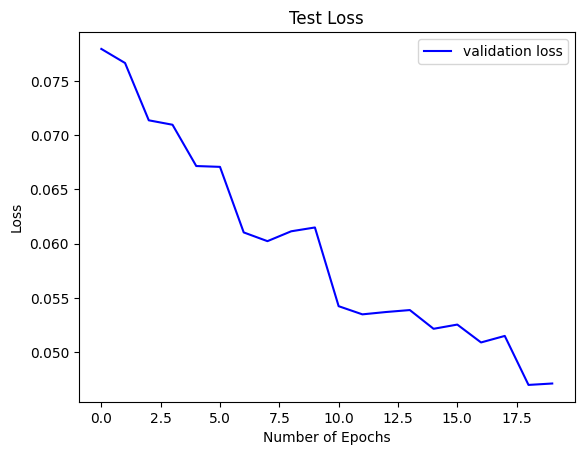

In [ ]:
# Plot the loss and accuracy curves for training and validation
plt.plot(history.history['val_loss'], color='b', label="validation loss")
plt.title("Test Loss")
plt.xlabel("Number of Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


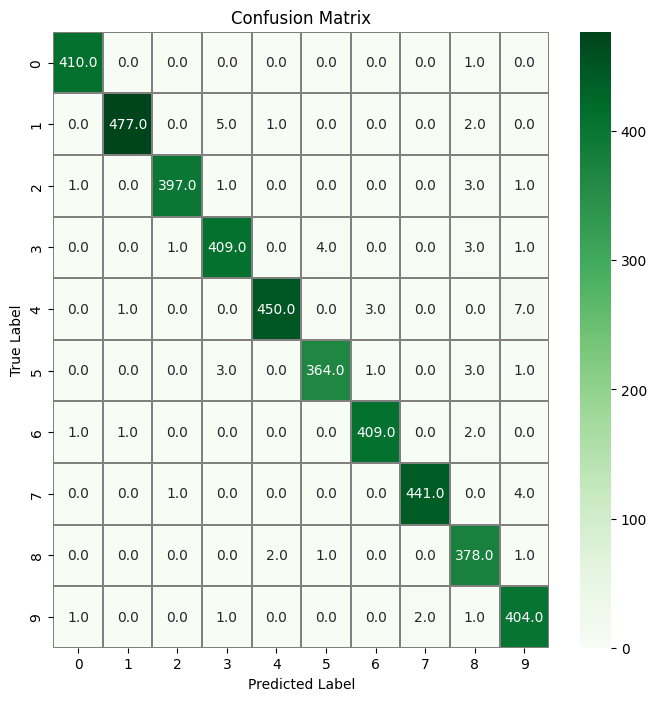

In [ ]:
# confusion matrix
import seaborn as sns
# Predict the values from the validation dataset
Y_pred = model.predict(X_val)
# Convert predictions classes to one hot vectors
Y_pred_classes = np.argmax(Y_pred,axis = 1)
# Convert validation observations to one hot vectors
Y_true = np.argmax(Y_val,axis = 1)
# compute the confusion matrix
confusion_mtx = confusion_matrix(Y_true, Y_pred_classes)
# plot the confusion matrix
f,ax = plt.subplots(figsize=(8, 8))
sns.heatmap(confusion_mtx, annot=True, linewidths=0.01,cmap="Greens",linecolor="gray", fmt= '.1f',ax=ax)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
from sklearn.metrics import classification_report

# Assuming y_true are your true labels and y_pred are your predicted labels
# For example, if you're working with a classification model like a CNN:
y_true =np.argmax(Y_val,axis = 1)   # Replace with your actual test labels
Y_pred = model.predict(X_val)
# Convert predictions classes to one hot vectors
Y_pred_classes = np.argmax(Y_pred,axis = 1)

# Print the classification report
print(classification_report(y_true, Y_pred_classes))


132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       411
           1       1.00      0.98      0.99       485
           2       0.99      0.99      0.99       403
           3       0.98      0.98      0.98       418
           4       0.99      0.98      0.98       461
           5       0.99      0.98      0.98       372
           6       0.99      0.99      0.99       413
           7       1.00      0.99      0.99       446
           8       0.96      0.99      0.98       382
           9       0.96      0.99      0.98       409

    accuracy                           0.99      4200
   macro avg       0.99      0.99      0.99      4200
weighted avg       0.99      0.99      0.99      4200



## Cifar dataset

In [2]:
import tensorflow as tf

from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


### Verify the data
To verify that the dataset looks correct, let's plot the first 25 images from the training set and display the class name below each image

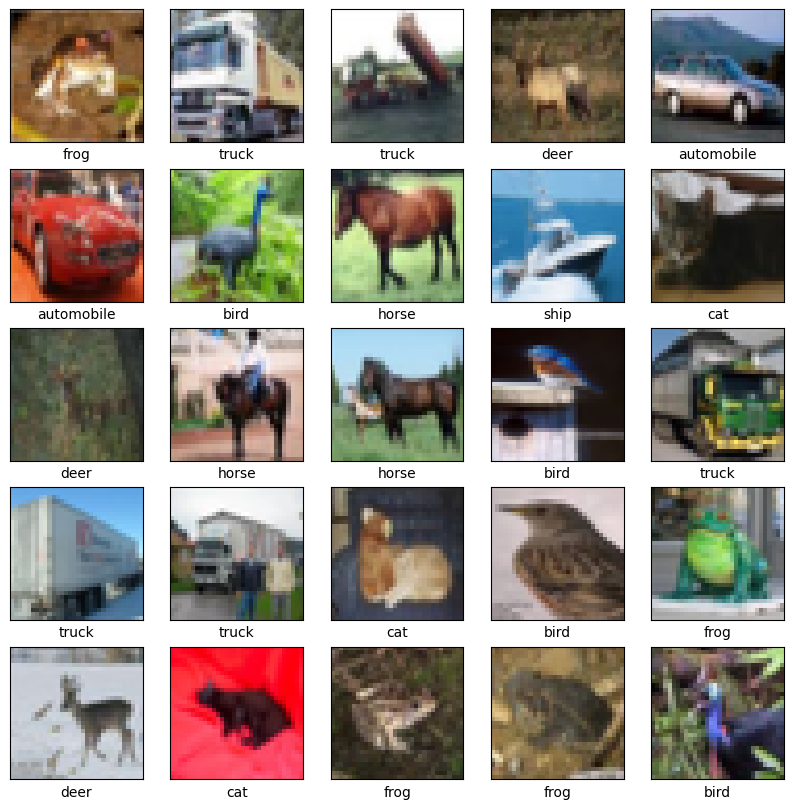

In [3]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    # The CIFAR labels happen to be arrays,
    # which is why you need the extra index
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

### Create the convolutional base

The 6 lines of code below define the convolutional base using a common pattern: a stack of Conv2D and MaxPooling2D layers.

As input, a CNN takes tensors of shape (image_height, image_width, color_channels), ignoring the batch size. If you are new to these dimensions, color_channels refers to (R,G,B). In this example, you will configure your CNN to process inputs of shape (32, 32, 3), which is the format of CIFAR images. You can do this by passing the argument input_shape to your first layer.

In [4]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 4, 4, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │          65,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

### Compile and train the model

In [6]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(train_images, train_labels, epochs=10,
                    validation_data=(test_images, test_labels))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 50ms/step - accuracy: 0.3464 - loss: 1.7691 - val_accuracy: 0.5279 - val_loss: 1.3100
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 45ms/step - accuracy: 0.5809 - loss: 1.1806 - val_accuracy: 0.6033 - val_loss: 1.1240
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 86s 47ms/step - accuracy: 0.6464 - loss: 1.0136 - val_accuracy: 0.6676 - val_loss: 0.9568
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 44ms/step - accuracy: 0.6868 - loss: 0.8939 - val_accuracy: 0.6769 - val_loss: 0.9168
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 45ms/step - accuracy: 0.7181 - loss: 0.8068 - val_accuracy: 0.6907 - val_loss: 0.8936
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 45ms/step - accuracy: 0.7387 - loss: 0.7441 - val_accuracy: 0.6886 - val_loss: 0.9075
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.7518 - loss: 0.7016 - val_accuracy: 0.7058 - val_loss: 0.8615
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.7735 -

### Evaluate the model

313/313 - 4s - 13ms/step - accuracy: 0.7013 - loss: 0.9373


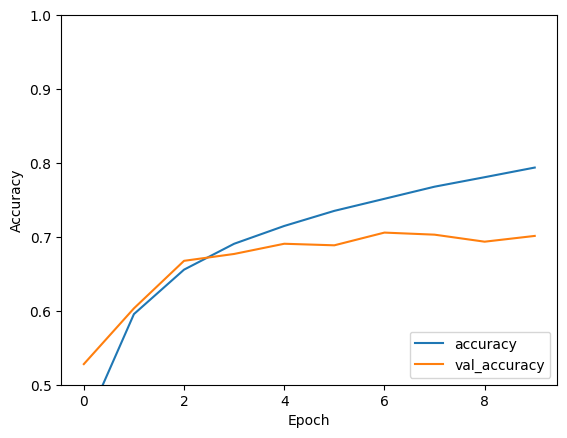

In [7]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)